# Single Layer Perceptron

# Overview
This Jupyter notebook goes through a simple simulation of one of the most basic of neural networks, a single layer perceptron, using plain matrix operations. We will learn how to do this by solving logic gate problems.

# Defining the problem
As with any simulation project, we start by defining the problem specifics.

# The "AND" problem.
---
- We restrict our problems to binary ones for the moment.
- We also restrict our simulation to the case of two binary inputs resulting in one binary output.
---
- Under this framing, the classic **AND** logic gate characterizes problems in which when *_all_* inputs are 1, the output is 1, and 0 otherwise.
- An ecological example might be based on the philosophical argument, expressed with possible statements as follows:

| Layer | Unit | Information (1) | Alternative Information (0) |
| --- | --- | --- | --- |
| Premise | a.i1 | All humans die | Not all humans die |
| Premise | a.i2 | Socrates is a human | Socrates is not a human |
| Conclusion | a.j | Socrates will die | Socrates will not die |

- In our human reasoning, there is only one situation in which the above table holds, which is that *a.i1 = 1*, *a.i2 = 1*, such that *a.j = 1*; and as long as either *a.i1* or *a.i2* are *0*, then *a.j = 0*.
- That is,

##Data table

This is the simulation's data table for which we want to model and solve, and incidentally, it is an **AND** logic table.

**Table 1.**

| a.i1 | a.i2 | a.j |
| --- | --- | --- |
| 1 | 1 | 1 |
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 0 |

##Hypothesis

A single-layer perceptron can behave in a way that corresponds to the above AND logic table, and thus can be an instance of an AND logic gate.



##Aim
- Make a single-layer perceptron with 2 input units, fully connected to a single output.
- Use the above model to implement an AND logic gate.

## Visualize architecture (optional)
Visualization helps us to keep track of the arrays, nodes, and edges that we need to implement. Here, I use the [Graphviz module](https://graphviz.org/) because it easily allows us to graphically work with nodes and edges in computational graphs (which are what neural networks are).

Single Layer Perceptron
2 inputs, 1 output



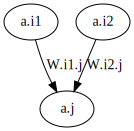

In [ ]:
# Visualize network architecture
from graphviz import Digraph

# Instantiate a new Graph object
dot = Digraph()

# Add nodes
dot.node('A', 'a.i1')
dot.node('B', 'a.i2')
dot.node('C', 'a.j')

# Add edges
dot.edge('A','C',label='W.i1.j')
dot.edge('B','C',label='W.i2.j')

# Show
print('\033[1mSingle Layer Perceptron\033[0m\n'+'2 inputs, 1 output\n')
dot

## Define the activation function
Note that the typical pre-activation function is,

\begin{equation*}
a_j^* = \vec{a_i}W
\tag{1}
\end{equation*}

The above is the simple sum of all weighted inputs. This may not always be the case. Mathematically, it is possible that some inputs might be products of each other. For simplicity, we will assume the simple sum case in general in this course.

Applying the pre-activation function to the activation function determines how inputs are integrated towards an output. Here, we will use the threshold function,

\begin{equation*}
a_j = \begin{cases}
1 & a_j^*>θ \\
0 & \text{otherwise}
\end{cases}\tag{2}
\end{equation*}

Eq. (1) is implemented in the following python definition, *af*, which takes three variables.
- a_i_s : A vector input *i* units over *s* states, which is effectively an array.
- W_ij : An array of weights between input *i* to output *j* unit(s).
- theta: A scalar threshold.

The definition returns an output vector, a_j.

In [ ]:
def af(a_i_s,W_ij,theta):
  a_j = max(np.sign(np.dot(a_i_s,W_ij)[0]-theta),0) # Nb: The dot product element is extracted to account for the way python applies the array dimensions.
  return a_j

## Create input state(s) array
The array consists of a 1 x 2 vectors (for the 2 input units) for each of the 4 rows of possible input states based on the data table, Table 1, and is effectively a 4 x 2 array.

In [ ]:
import numpy as np # load numpy module for array manipulation

a_i = np.array([[1,1],
         [1,0],
         [0,1],
         [0,0]])

print('Input data:\n',a_i,'\nThe array has size ',a_i.shape)

Input data:
 [[1 1]
 [1 0]
 [0 1]
 [0 0]] 
The array has size  (4, 2)


## Try weight and theta values

In [ ]:
# Set weights (W_ij), which is a 2 x 1 array.
W_ij = np.array([[0.8],
         [0.5]])

# Set scalar theta
theta = 0.8

print('W_ij : ',W_ij)
print('theta : ',theta)

W_ij :  [[0.8]
 [0.5]]
theta :  0.8


## Evaluate the model
Apply the set weights and thresholds on the inputs, looping over the 4 possible states.

In [ ]:
a_j = np.zeros((4,1))
print('|a.i1 |','a.i2 |','a.j.hat\t|')
print('|-----|','-----|','--------\t|')

for s in np.arange(0,a_i.shape[0]): # loop over the possible states
  a_i_s = a_i[s,:] # a_i_s is a 1 x 2 array
  a_j[s] = int(af(a_i_s,W_ij,theta))
  print('|',a_i_s[0],'  |',a_i_s[1],'   |',int(af(a_i_s,W_ij,theta)),'\t|') # af output is set to be integer

|a.i1 | a.i2 | a.j.hat	|
|-----| -----| --------	|
| 1   | 1    | 1 	|
| 1   | 0    | 0 	|
| 0   | 1    | 0 	|
| 0   | 0    | 0 	|


## Do some fancy plotting.

In [ ]:
import plotly.graph_objects as go
import plotly.subplots as sp

colorscale = [(0,"rgb(225,225,225)"), (1,"rgb(100,100,100)")]
zmin = 0
zmax = 1
xgap = 0
ygap = 0
textfont = {'size':10}
showscale = True

fig = sp.make_subplots(rows=2, cols=2,
                      specs=[[{"type": "heatmap"}, None],
                             [{"type": "heatmap"}, {"type": "heatmap"}]],
                      subplot_titles=("$a_i$", "$W_{ij}$", ""))

fig.add_trace(go.Heatmap(z=a_i,x=['i1','i2'],y=['s1','s2','s3','s4'], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=a_i, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=1, col=1)
fig.add_trace(go.Heatmap(z=W_ij.T,x=['i1j','i2j'],y=[""], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=W_ij.T, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=2, col=1)
fig.add_trace(go.Heatmap(z=a_j.T,y=["$a_j$"], x=['s1','s2','s3','s4'], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=a_j.T, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=2, col=2)

fig.update_layout(plot_bgcolor="rgb(0,0,0)",height=400, width=600, title_text="An AND Logic Gate using Single Layer Perceptron")
fig.show()


## Make a form AND logic gate calculator

In [ ]:
# @title AND Gate Calculator {"run":"auto","vertical-output":true}
ai = 1, 1 # @param {"type":"raw","placeholder":"0,0"}
Wij = 0.3, 0.8 # @param {"type":"raw","placeholder":"0,0"}
t = 0.8 # @param {"type":"number","placeholder":"0"}

print('|a.i1 |','a.i2 |','a.j.hat\t|')
print('|-----|','-----|','--------\t|')
print('|',ai[0],'  |',ai[1],'   |',int(af(np.array(ai),np.array([Wij]).T,t)),'\t|')

|a.i1 | a.i2 | a.j.hat	|
|-----| -----| --------	|
| 1   | 1    | 1 	|


## Discussion
- Is the above model performance as expected?
- How did you decide on the weights and threshold? How might you change them?
- Note that I labelled the output unit as a.j.hat, $\hat{a_j}$. Why do you think that is that case?
- What happens if we remove the threshold function and just do $a_j=W\vec{a_i}$?
- Try visualizing the model on a 3D plot (clue: use a_i1, a_i2, and a.j.hat as the three axes of the plot).

___
# Try the following yourself.
___

# The 'OR' problem.
##Data table

This is the simulation's data table for which we want to model and solve, and incidentally, it is an **OR** logic table.

**Table 2.**

| a.i1 | a.i2 | a.j |
| --- | --- | --- |
| 1 | 1 | 1 |
| 1 | 0 | 1 |
| 0 | 1 | 1 |
| 0 | 0 | 0 |

In [ ]:
# @title OR Gate Calculator {"run":"auto","vertical-output":true}
ai = [1, 1],[0,1],[1,0],[0,0] # @param {"type":"raw","placeholder":"0,0"}
Wij = [1], [1.4] # @param {"type":"raw","placeholder":"0,0"}
t = 0.8 # @param {"type":"number","placeholder":"0"}

# Convert raw input to arrays
ai = np.array(ai)
Wij = np.array(Wij)

print('|a.i1 |','a.i2 |','a.j.hat\t|')
print('|-----|','-----|','--------\t|')

for s in np.arange(0,ai.shape[0]): # loop over the possible states
  ai_s = ai[s,:]
  a_j[s] = int(af(ai_s,Wij,t))
  print('|',ai_s[0],'  |',ai_s[1],'   |',int(a_j[s][0]),'\t|')

# Fancy plot
import plotly.graph_objects as go
import plotly.subplots as sp

colorscale = [(0,"rgb(225,225,225)"), (1,"rgb(100,100,100)")]
zmin = 0
zmax = 1
xgap = 0
ygap = 0
textfont = {'size':10}
showscale = True

fig = sp.make_subplots(rows=2, cols=2,specs=[[{"type": "heatmap"}, None],[{"type": "heatmap"}, {"type": "heatmap"}]],
                      subplot_titles=("$a_i$", "$W_{ij}$", ""))

fig.add_trace(go.Heatmap(z=ai,x=['i1','i2'],y=['s1','s2','s3','s4'], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=a_i, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=1, col=1)
fig.add_trace(go.Heatmap(z=Wij.T,x=['i1j','i2j'],y=[""], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=W_ij.T, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=2, col=1)
fig.add_trace(go.Heatmap(z=a_j.T,y=["$a_j$"], x=['s1','s2','s3','s4'], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=a_j.T, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=2, col=2)

fig.update_layout(plot_bgcolor="rgb(0,0,0)",height=300, width=500, title_text="An OR Logic Gate using Single Layer Perceptron")
fig.show()

|a.i1 | a.i2 | a.j.hat	|
|-----| -----| --------	|
| 1   | 1    | 1 	|
| 0   | 1    | 1 	|
| 1   | 0    | 1 	|
| 0   | 0    | 0 	|


# The 'XOR' problem.
##Data table

This is the simulation's data table for which we want to model and solve, and incidentally, it is an **XOR** logic table.

**Table 3.**

| a.i1 | a.i2 | a.j |
| --- | --- | --- |
| 1 | 1 | 0 |
| 1 | 0 | 1 |
| 0 | 1 | 1 |
| 0 | 0 | 0 |

In [ ]:
# @title XOR Gate Calculator (FAILS!!) {"run":"auto","vertical-output":true}
ai = [1, 1],[0,1],[1,0],[0,0] # @param {"type":"raw","placeholder":"0,0"}
Wij = [0.5], [0.5] # @param {"type":"raw","placeholder":"0,0"}
t = 0.5 # @param {"type":"number","placeholder":"0"}

# Convert raw input to arrays
ai = np.array(ai)
Wij = np.array(Wij)

print('|a.i1 |','a.i2 |','a.j.hat\t|')
print('|-----|','-----|','--------\t|')

for s in np.arange(0,ai.shape[0]): # loop over the possible states
  ai_s = ai[s,:]
  a_j[s] = int(af(ai_s,Wij,t))
  print('|',ai_s[0],'  |',ai_s[1],'   |',int(a_j[s][0]),'\t|')

# Fancy plot
import plotly.graph_objects as go
import plotly.subplots as sp

colorscale = [(0,"rgb(225,225,225)"), (1,"rgb(100,100,100)")]
zmin = 0
zmax = 1
xgap = 0
ygap = 0
textfont = {'size':10}
showscale = True

fig = sp.make_subplots(rows=2, cols=2,specs=[[{"type": "heatmap"}, None],[{"type": "heatmap"}, {"type": "heatmap"}]],
                      subplot_titles=("$a_i$", "$W_{ij}$", ""))

fig.add_trace(go.Heatmap(z=ai,x=['i1','i2'],y=['s1','s2','s3','s4'], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=a_i, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=1, col=1)
fig.add_trace(go.Heatmap(z=Wij.T,x=['i1j','i2j'],y=[""], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=W_ij.T, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=2, col=1)
fig.add_trace(go.Heatmap(z=a_j.T,y=["$a_j$"], x=['s1','s2','s3','s4'], colorscale=colorscale, zmin=zmin, zmax=zmax, xgap = xgap, ygap = ygap, text=a_j.T, texttemplate="%{text}", textfont=textfont, showscale=showscale), row=2, col=2)

fig.update_layout(plot_bgcolor="rgb(0,0,0)",height=300, width=500, title_text="An OR Logic Gate using Single Layer Perceptron")
fig.show()

|a.i1 | a.i2 | a.j.hat	|
|-----| -----| --------	|
| 1   | 1    | 1 	|
| 0   | 1    | 0 	|
| 1   | 0    | 0 	|
| 0   | 0    | 0 	|


# The extended 'AND' problem I - 'NAND'
##Data table

This is the simulation's data table for which we want to model and solve.

**Table 5.**

| a.i1 | a.i2 | a.j1 | a.j2 |
| --- | --- | --- | --- |
| 1 | 1 | 1 | 0 |
| 1 | 0 | 0 | 0 |
| 0 | 1 | 0 | 0 |
| 0 | 0 | 0 | 1 |

# The extended 'AND' problem II.
##Data table

This is the simulation's data table for which we want to model and solve.

**Table 4.**

| a.i1 | a.i2 | a.i3 | a.j |
| --- | --- | --- | --- |
| 1 | 1 | 1 | 1 |
| 1 | 1 | 0 | 0 |
| 1 | 0 | 1 | 0 |
| 0 | 1 | 1 | 0 |
| 0 | 1 | 0 | 0 |
| 0 | 0 | 1 | 0 |
| 1 | 0 | 0 | 0 |
| 0 | 0 | 0 | 0 |